# Customer Churn Prediction - Exploratory Data Analysis (EDA)

## Objective

The goal of this notebook is to explore the customer churn dataset, identify patterns, discover business insights, and understand the factors that influence customer churn.

### Steps

- Load Cleaned Dataset
- Understand Target Variable
- Univariate Analysis
- Bivariate Analysis
- Correlation Analysis
- Business Insights

Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

Load Cleaned Dataset

In [4]:
df = pd.read_csv("../data/processed/cleaned_customer_churn.csv")

Display Dataset

In [5]:
df.head()

,customer_id,age_group,gender,region,customer_segment,preferred_channel,purchase_frequency,avg_order_value,total_spent,recency_days,website_visits,discount_usage_rate,email_open_rate,cart_abandonment_rate,loyalty_score,engagement_score,churn_risk,churn_flag
0,C000001,18-24,Other,North,Loyal,Online,5,381.27,2108.80,189,27,0.38,0.13,0.42,33,35.5,Medium,1
1,C000002,25-34,Other,South,New,Mobile App,12,376.65,3843.06,277,68,0.51,0.06,0.07,68,49.5,Medium,1
2,C000003,55+,Other,North,VIP,Online,5,37.73,224.65,271,23,0.64,0.22,0.46,73,38.0,High,1
3,C000004,18-24,Male,North,Returning,Mobile App,12,191.19,1960.79,89,93,0.66,0.31,0.13,93,59.0,Low,0
4,C000005,55+,Other,North,Returning,Mobile App,2,279.64,594.79,264,4,0.73,0.27,0.58,11,34.5,High,1


In [6]:
print(df.shape)

(100000, 18)


In [7]:
df["churn_flag"].value_counts()

churn_flag
0    53776
1    46224
Name: count, dtype: int64

In [8]:
(df["churn_flag"].value_counts(normalize=True) * 100).round(2)

churn_flag
0    53.78
1    46.22
Name: proportion, dtype: float64

Plot Churn Distribution

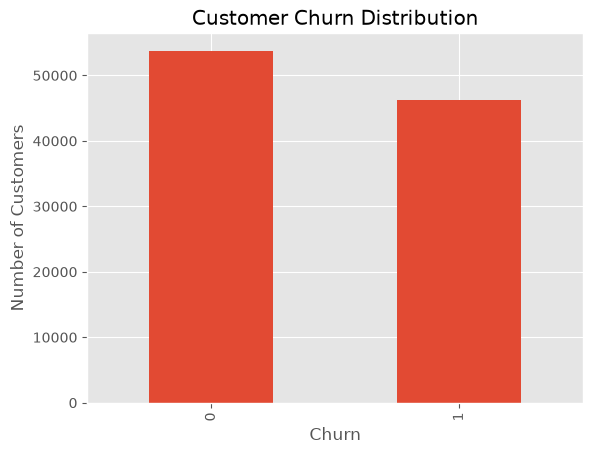

In [9]:
df["churn_flag"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

Age Group Distribution

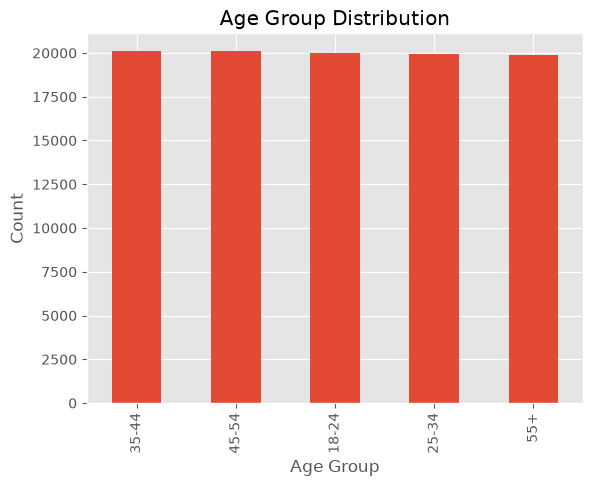

In [10]:
df["age_group"].value_counts().plot(kind="bar")

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.show()

Gender Distribution

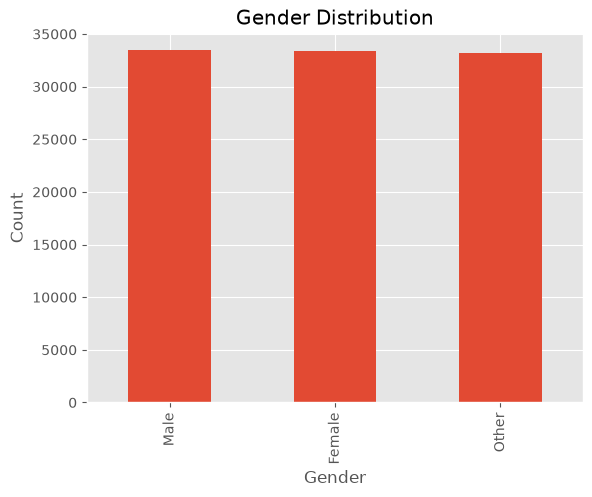

In [11]:
df["gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

Region Distribution

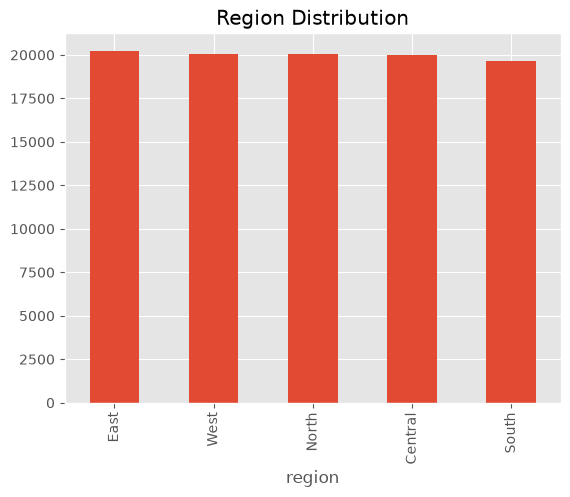

In [12]:
df["region"].value_counts().plot(kind="bar")

plt.title("Region Distribution")

plt.show()

Customer Segment|

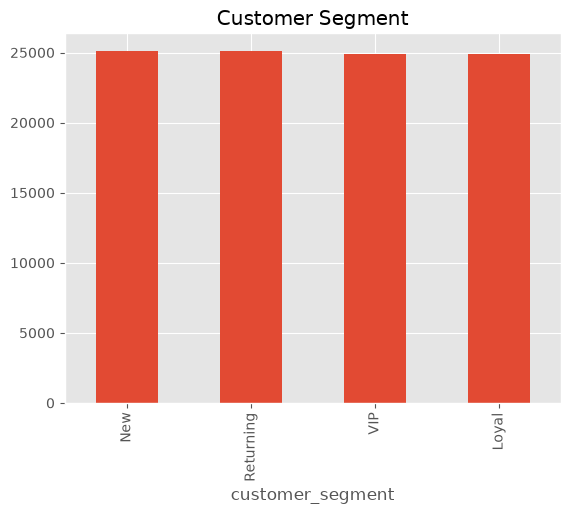

In [13]:
df["customer_segment"].value_counts().plot(kind="bar")

plt.title("Customer Segment")

plt.show()

Preferred Channel

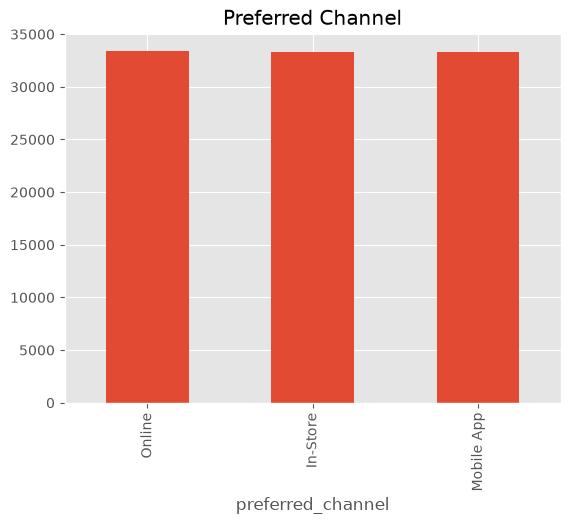

In [14]:
df["preferred_channel"].value_counts().plot(kind="bar")

plt.title("Preferred Channel")

plt.show()

Purchase Frequency

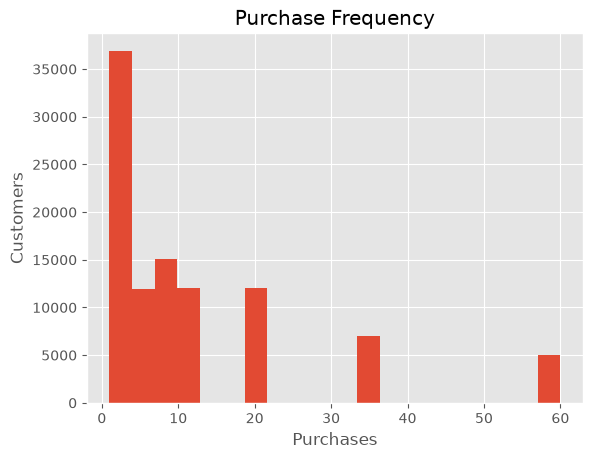

In [15]:
plt.hist(df["purchase_frequency"], bins=20)

plt.title("Purchase Frequency")

plt.xlabel("Purchases")

plt.ylabel("Customers")

plt.show()

Average Order Value

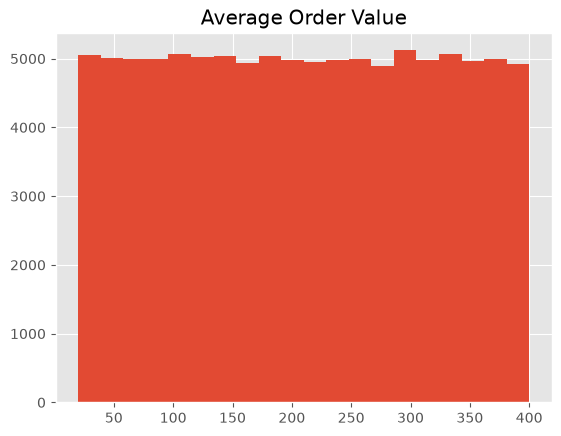

In [16]:
plt.hist(df["avg_order_value"], bins=20)

plt.title("Average Order Value")

plt.show()

Total Spent

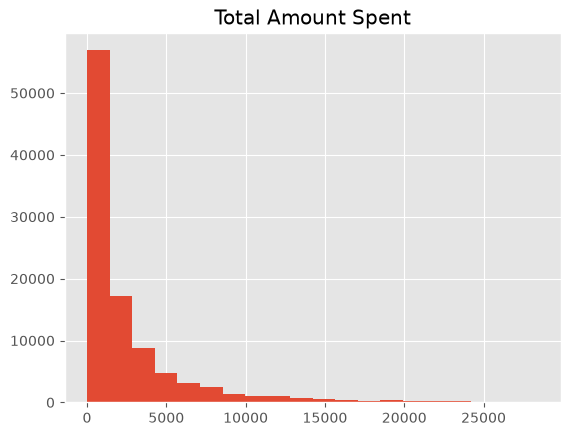

In [17]:
plt.hist(df["total_spent"], bins=20)

plt.title("Total Amount Spent")

plt.show()

Website Visits

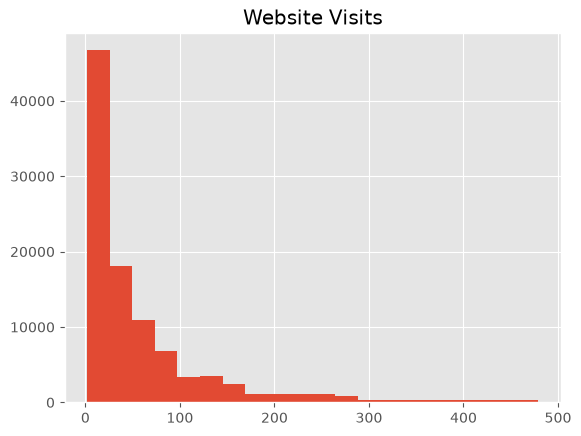

In [18]:
plt.hist(df["website_visits"], bins=20)

plt.title("Website Visits")

plt.show()

Loyalty Score

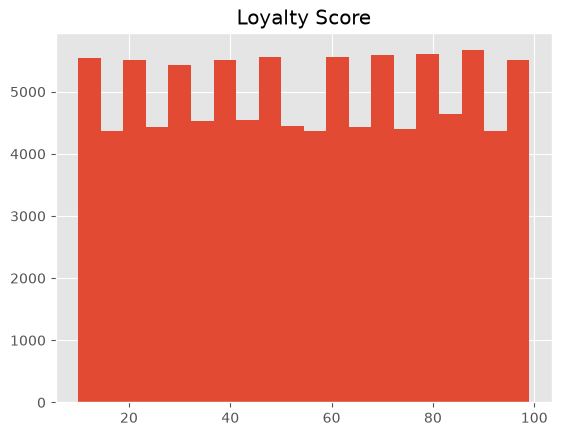

In [19]:
plt.hist(df["loyalty_score"], bins=20)

plt.title("Loyalty Score")

plt.show()

Correlation Matrix

In [20]:
numeric_df = df.select_dtypes(include=np.number)

numeric_df.corr()

,purchase_frequency,avg_order_value,total_spent,recency_days,website_visits,discount_usage_rate,email_open_rate,cart_abandonment_rate,loyalty_score,engagement_score,churn_flag
purchase_frequency,1.000000,0.004561,0.822762,-0.001743,0.912442,0.005852,0.000301,0.000868,0.004925,-0.000375,-0.049854
avg_order_value,0.004561,1.000000,0.356315,-0.002742,0.003649,-0.001216,-0.002264,0.001431,0.003118,-0.002631,-0.004330
total_spent,0.822762,0.356315,1.000000,-0.001523,0.751104,0.005232,-0.001756,0.002216,0.005769,-0.002797,-0.042300
recency_days,-0.001743,-0.002742,-0.001523,1.000000,-0.002522,0.000842,0.001250,0.004663,0.003310,-0.002282,0.774030
website_visits,0.912442,0.003649,0.751104,-0.002522,1.000000,0.006467,-0.000578,0.001231,0.003757,-0.001265,-0.044094
discount_usage_rate,0.005852,-0.001216,0.005232,0.000842,0.006467,1.000000,0.006324,-0.004391,-0.005493,0.007618,0.001864
email_open_rate,0.000301,-0.002264,-0.001756,0.001250,-0.000578,0.006324,1.000000,0.000537,-0.002160,0.728728,0.002463
cart_abandonment_rate,0.000868,0.001431,0.002216,0.004663,0.001231,-0.004391,0.000537,1.000000,-0.001328,-0.684412,0.228116
loyalty_score,0.004925,0.003118,0.005769,0.003310,0.003757,-0.005493,-0.002160,-0.001328,1.000000,-0.000665,-0.175249
engagement_score,-0.000375,-0.002631,-0.002797,-0.002282,-0.001265,0.007618,0.728728,-0.684412,-0.000665,1.000000,-0.154419


Correlation Heatmap

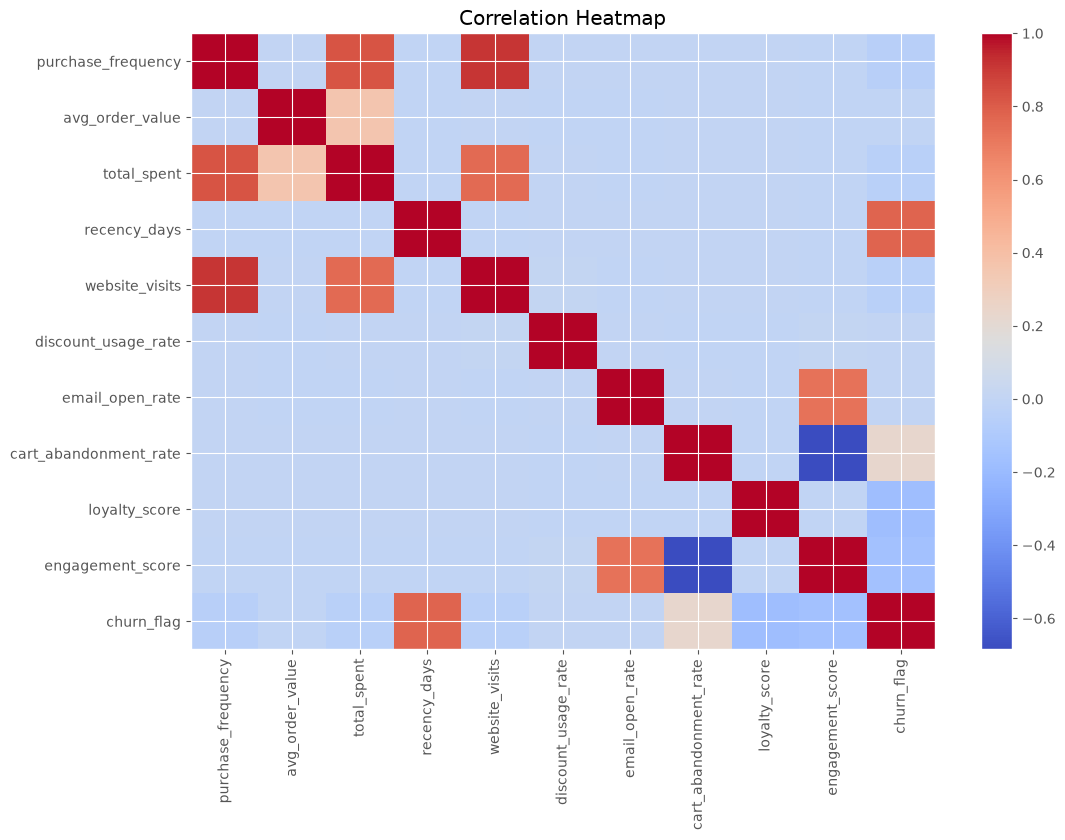

In [21]:
corr = numeric_df.corr()

plt.figure(figsize=(12,8))

plt.imshow(corr, cmap="coolwarm", aspect="auto")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar()

plt.title("Correlation Heatmap")

plt.show()

Save the Plots

In [22]:
import os

os.makedirs("../outputs/plots", exist_ok=True)

## Business Insights

- Most customers belong to the **Loyal** segment.
- The **North** region has the highest number of customers.
- The churn rate is approximately **X%**.
- Customers with low loyalty scores appear more likely to churn.
- Higher purchase frequency is associated with greater customer retention.